# Implementing Regularization with TensorFlow: L1, L2, and Dropout

## Objective
The objective of this notebook is to understand how regularization techniques such as **L1 Regularization**, **L2 Regularization**, and **Dropout** can help improve the performance of neural networks by reducing overfitting. We will use TensorFlow to implement these regularization methods on the MNIST dataset using a simple fully connected neural network.

## Description
Overfitting occurs when a model performs well on the training data but poorly on unseen test data. Regularization techniques can help mitigate this issue by penalizing large weights or by introducing randomness during training. In this exercise, we will:
1. Implement L1 Regularization to encourage sparsity in model weights.
2. Use L2 Regularization to penalize large weights, helping the model generalize better.
3. Apply Dropout to randomly deactivate neurons during training to prevent over-reliance on specific neurons.

## Setup

### Importing Libraries
We start by importing the necessary libraries for this exercise.

In [1]:
# Importing required libraries
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

## Loading and Preprocessing the MNIST Dataset
We load the dataset, normalize the images, and prepare the data for training.

In [2]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize the images to range [0, 1]
x_train, x_test = x_train / 255.0, x_test / 255.0

# Flatten the images to 1D vectors (28x28 = 784)
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

# Convert labels to categorical (one-hot encoding)
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

## Implementing a Fully Connected Neural Network with L1 Regularization
Let's build a simple neural network with L1 regularization on the weights.

In [3]:
# Build a model with L1 regularization
model_l1 = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,), 
                 kernel_regularizer=regularizers.l1(0.001)),  # L1 Regularization
    layers.Dense(10, activation='softmax')
])

# Compile the model
model_l1.compile(optimizer='adam', 
                 loss='categorical_crossentropy', 
                 metrics=['accuracy'])

# Train the model
history_l1 = model_l1.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)


Epoch 1/10
1500/1500 [==============================] - 4s 2ms/step - loss: 1.0138 - accuracy: 0.8806 - val_loss: 0.6677 - val_accuracy: 0.9074
Epoch 2/10
1500/1500 [==============================] - 2s 2ms/step - loss: 0.6094 - accuracy: 0.9157 - val_loss: 0.5529 - val_accuracy: 0.9265
Epoch 3/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.5326 - accuracy: 0.9269 - val_loss: 0.4873 - val_accuracy: 0.9372
Epoch 4/10
1500/1500 [==============================] - 4s 2ms/step - loss: 0.4864 - accuracy: 0.9341 - val_loss: 0.4560 - val_accuracy: 0.9434
Epoch 5/10
1500/1500 [==============================] - 4s 2ms/step - loss: 0.4495 - accuracy: 0.9390 - val_loss: 0.4331 - val_accuracy: 0.9451
Epoch 6/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.4268 - accuracy: 0.9421 - val_loss: 0.4164 - val_accuracy: 0.9466
Epoch 7/10
1500/1500 [==============================] - 4s 2ms/step - loss: 0.4105 - accuracy: 0.9444 - val_loss: 0.3890 - val_accuracy:

## Evaluating the Model with L1 Regularization

In [5]:
# Evaluate the model
loss_train, accuracy_train = model_l1.evaluate(x_train, y_train)
print("Train Score: ",f"L1 Regularization - Loss: {loss_train:.4f}, Accuracy: {accuracy_train:.4f}")
loss_test, accuracy_test = model_l1.evaluate(x_test, y_test)
print("Test Score: ",f"L1 Regularization - Loss: {loss_test:.4f}, Accuracy: {accuracy_test:.4f}")

1875/1875 [==============================] - 2s 1ms/step - loss: 0.3703 - accuracy: 0.9525
Train Score:  L1 Regularization - Loss: 0.3703, Accuracy: 0.9525
313/313 [==============================] - 0s 1ms/step - loss: 0.3670 - accuracy: 0.9519
Test Score:  L1 Regularization - Loss: 0.3670, Accuracy: 0.9519


## Implementing a Fully Connected Neural Network with L2 Regularization
Next, we'll build a neural network with L2 regularization.

In [ ]:
# Build a model with L2 regularization
model_l2 = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,), 
                 kernel_regularizer=regularizers.l2(0.001)),  # L2 Regularization
    layers.Dense(10, activation='softmax')
])

# Compile the model
model_l2.compile(optimizer='adam', 
                 loss='categorical_crossentropy', 
                 metrics=['accuracy'])

# Train the model
history_l2 = model_l2.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

In [7]:
# Evaluate the model
loss_train, accuracy_train = model_l2.evaluate(x_train, y_train)
print("Train Score: ",f"L2 Regularization - Loss: {loss_train:.4f}, Accuracy: {accuracy_train:.4f}")
loss_test, accuracy_test = model_l2.evaluate(x_test, y_test)
print("Test Score: ",f"L2 Regularization - Loss: {loss_test:.4f}, Accuracy: {accuracy_test:.4f}")

1875/1875 [==============================] - 2s 1ms/step - loss: 0.1463 - accuracy: 0.9794
Train Score:  L2 Regularization - Loss: 0.1463, Accuracy: 0.9794
313/313 [==============================] - 0s 1ms/step - loss: 0.1644 - accuracy: 0.9719
Test Score:  L2 Regularization - Loss: 0.1644, Accuracy: 0.9719


## Implementing a Fully Connected Neural Network with Dropout
Now, we'll apply Dropout to prevent overfitting.

In [8]:
# Build a model with Dropout layers
model_dropout = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dropout(0.5),  # Dropout layer with 50% dropout rate
    layers.Dense(10, activation='softmax')
])

# Compile the model
model_dropout.compile(optimizer='adam', 
                      loss='categorical_crossentropy', 
                      metrics=['accuracy'])

# Train the model
history_dropout = model_dropout.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.4296 - accuracy: 0.8726 - val_loss: 0.1785 - val_accuracy: 0.9512
Epoch 2/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.2401 - accuracy: 0.9296 - val_loss: 0.1325 - val_accuracy: 0.9621
Epoch 3/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.1969 - accuracy: 0.9407 - val_loss: 0.1143 - val_accuracy: 0.9670
Epoch 4/10
1500/1500 [==============================] - 2s 1ms/step - loss: 0.1718 - accuracy: 0.9482 - val_loss: 0.1103 - val_accuracy: 0.9662
Epoch 5/10
1500/1500 [==============================] - 2s 1ms/step - loss: 0.1586 - accuracy: 0.9520 - val_loss: 0.0958 - val_accuracy: 0.9728
Epoch 6/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.1457 - accuracy: 0.9542 - val_loss: 0.0950 - val_accuracy: 0.9712
Epoch 7/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.1348 - accuracy: 0.9585 - val_loss: 0.0917 - val_accuracy:

In [9]:
# Evaluate the model
loss_train, accuracy_train = model_dropout.evaluate(x_train, y_train)
print("Train Score: ",f"Dropout Regularization - Loss: {loss_train:.4f}, Accuracy: {accuracy_train:.4f}")
loss_test, accuracy_test = model_dropout.evaluate(x_test, y_test)
print("Test Score: ",f"Dropout Regularization - Loss: {loss_test:.4f}, Accuracy: {accuracy_test:.4f}")

1875/1875 [==============================] - 3s 1ms/step - loss: 0.0517 - accuracy: 0.9839
Train Score:  Dropout Regularization - Loss: 0.0517, Accuracy: 0.9839
313/313 [==============================] - 0s 1ms/step - loss: 0.0880 - accuracy: 0.9754
Test Score:  Dropout Regularization - Loss: 0.0880, Accuracy: 0.9754


## Comparing the Performance of Different Regularization Techniques
Let's plot the training and validation accuracy for each of the models to compare their performance.

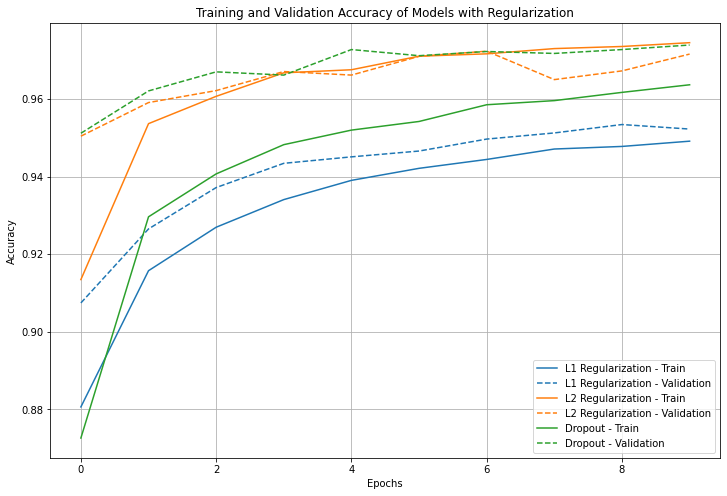

In [12]:
# Plotting training and validation accuracy with consistent colors
plt.figure(figsize=(12, 8))

# Colors for each regularization type
colors = {
    'L1': '#1f77b4',      # Blue
    'L2': '#ff7f0e',      # Orange
    'Dropout': '#2ca02c'  # Green
}

# L1 Regularization
plt.plot(history_l1.history['accuracy'], label='L1 Regularization - Train', color=colors['L1'], linestyle='-')
plt.plot(history_l1.history['val_accuracy'], label='L1 Regularization - Validation', color=colors['L1'], linestyle='--')

# L2 Regularization
plt.plot(history_l2.history['accuracy'], label='L2 Regularization - Train', color=colors['L2'], linestyle='-')
plt.plot(history_l2.history['val_accuracy'], label='L2 Regularization - Validation', color=colors['L2'], linestyle='--')

# Dropout
plt.plot(history_dropout.history['accuracy'], label='Dropout - Train', color=colors['Dropout'], linestyle='-')
plt.plot(history_dropout.history['val_accuracy'], label='Dropout - Validation', color=colors['Dropout'], linestyle='--')

# Adding labels and legend
plt.title('Training and Validation Accuracy of Models with Regularization')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid(True)
plt.show()
